# Starfall Serpents Esports — Predicting Match Outcomes in Competitive League of Legends (2024)

**Ismail Jhaveri, Aitemir Kermaliev, Izaac Martinez, Kadiatou Sogodogo | ISM-6251**

## Who We Are

Starfall Serpents Esports is a competitive esports organization focused on helping our players perform at the highest level. Our goal is to use data-driven insights to strengthen strategy, improve decision-making, and give our team a long-term competitive edge.

## What is League of Legends

League of Legends is a fast-paced, objective-based game where two teams fight for map control, secure neutral objectives, and ultimately destroy the enemy Nexus. Success relies on strategy, coordination, and real-time decision making, making it a perfect fit for analytics.

## Our Dataset

We analyzed thousands of competitive match records containing team performance metrics such as gold, kills, objectives (dragons, barons, towers), game length, and more. This dataset allows us to model which in-game actions most strongly influence win probability.

## Why This Matters

By identifying the features that consistently predict victory, we can help the Starfall Serpents refine gameplay priorities, optimize practice routines, and build strategies that give our players the highest chance of winning on stage.

## Our Strategic Overview

**Our Goal**
- Understand what actually influences win probability
- Build a data-driven foundation for team strategy
- Help the Starfall Serpents improve performance over time

**Our Approach**
- Collect professional match data
- Clean, align, and structure it for modeling
- Build models to predict win probability
- Compare approaches to see what works best

**What We Analyzed**
- Team performance metrics
- Tempo, economy, and objective stats
- Match-level behavior across thousands of games
- Patterns that may correlate with winning

**Why It Matters**
- Better insights guide smarter practice
- Helps coaches focus on what truly impacts outcomes
- Supports long-term competitive growth
- Moves the team from intuition to evidence-based decisions

## Important Note on Feature Types and Data Leakage

This dataset contains two fundamentally different types of features:

- **In-game process features** — metrics that reflect decisions and actions taken during the match (e.g., gamelength, team_kpm, dragons, barons). These are valid predictors.
- **Post-game outcome features** — metrics only fully known after the match ends (e.g., totalgold, towers, final kills totals, inhibitors). Using these constitutes data leakage, producing unrealistically high accuracy.

Many features in this dataset are post-game statistics. The high model accuracies reflect this leakage rather than true predictive power. We acknowledge this throughout and discuss it in the Reflections section. A production-ready model would restrict features to those available at a defined prediction point such as the 15-minute mark.


In [1]:
# =========================
# Imports & Setup
# =========================

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
def h1(s): print(f"\n{'='*len(s)}\n{s}\n{'='*len(s)}")
def h2(s): print(f"\n{s}\n{'-'*len(s)}")

import numpy, sklearn, matplotlib
print("Versions → numpy:", numpy.__version__,
      "| scikit-learn:", sklearn.__version__,
      "| pandas:", pd.__version__,
      "| matplotlib:", matplotlib.__version__)
print(" Environment OK")


Versions → numpy: 2.2.5 | scikit-learn: 1.7.1 | pandas: 2.3.2 | matplotlib: 3.10.5
 Environment OK


**Explanation**  
This section imports all required libraries and defines utility functions (h1, h2) used for section headings throughout the notebook. Install any missing packages with pip install numpy pandas scikit-learn imbalanced-learn matplotlib.


In [2]:
# =========================
# Data Loading
# =========================

import pandas as pd
import numpy as np
from pathlib import Path

h1("Load Dataset")

DATA_FILE = Path("2024_LoL_esports_match_data_from_OraclesElixir.xlsx")

if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"'{DATA_FILE}' not found. Make sure it is in the same folder as this notebook."
    )

df = pd.read_excel(DATA_FILE, engine="openpyxl")

print("Loaded successfully. Shape:", df.shape)
print(df.head())



Load Dataset
Loaded successfully. Shape: (12276, 123)
               gameid datacompleteness  \
0  10660-10660_game_1          partial   
1  10660-10660_game_1          partial   
2  10660-10660_game_1          partial   
3  10660-10660_game_1          partial   
4  10660-10660_game_1          partial   

                                            url league  year split  playoffs  \
0  https://lpl.qq.com/es/stats.shtml?bmid=10660   DCup  2023   NaN         0   
1  https://lpl.qq.com/es/stats.shtml?bmid=10660   DCup  2023   NaN         0   
2  https://lpl.qq.com/es/stats.shtml?bmid=10660   DCup  2023   NaN         0   
3  https://lpl.qq.com/es/stats.shtml?bmid=10660   DCup  2023   NaN         0   
4  https://lpl.qq.com/es/stats.shtml?bmid=10660   DCup  2023   NaN         0   

                 date  game  patch  ...  opp_csat15 golddiffat15 xpdiffat15  \
0 2024-01-01 05:13:15     1  13.24  ...         NaN          NaN        NaN   
1 2024-01-01 05:13:15     1  13.24  ...         NaN  

**Explanation**  
This cell loads the dataset directly from the Excel file in the project folder using pandas. No internet connection or API token is required. The openpyxl engine is used to read the .xlsx format.


In [3]:
# =========================
# Normalize Column Names & Null Summary
# =========================

h1("Normalize Columns & Null Summary")

# Normalize column names to lower_snake_case
def normalize_cols(columns):
    out = []
    for c in columns:
        c2 = c.strip().replace(" ", "_").replace("/", "_").replace("-", "_")
        c2 = c2.replace("(", "").replace(")", "")
        out.append(c2.lower())
    return out

df.columns = normalize_cols(df.columns)

h2("Columns & Types")
print(df.dtypes.value_counts())

h2("Null Summary (top 20)")
nulls = df.isna().sum().sort_values(ascending=False)
print(nulls[nulls > 0].head(20))



Normalize Columns & Null Summary

Columns & Types
---------------
float64           85
int64             20
object            17
datetime64[ns]     1
Name: count, dtype: int64

Null Summary (top 20)
---------------------
dragons_type_unknown    11902
firsttower              10604
oceans                  10604
opp_turretplates        10604
turretplates            10604
firstdragon             10604
elementaldrakes         10604
opp_elementaldrakes     10604
infernals               10604
mountains               10604
clouds                  10604
chemtechs               10604
hextechs                10604
elders                  10604
opp_elders              10604
firstherald             10604
heralds                 10604
opp_heralds             10604
firstbaron              10604
firsttothreetowers      10604
dtype: int64


**Explanation**  
This cell normalizes all column names to lower_snake_case for consistent downstream access, then prints a summary of column types and missing value counts. These steps ensure that preprocessing and modeling remain stable regardless of the original CSV formatting.


In [4]:
# =========================
# Team → Player backfill & drop team rows (vectorized; no downstream breaks)
# Place this RIGHT AFTER the "Load (auto-detect delimiter)" cell
# =========================
import pandas as pd

def _pick(cols, options, name):
    for o in options:
        if o in cols:
            return o
    raise KeyError(f"Required column for {name} not found. Tried: {options}")

cols = set(df.columns)

# Your notebook lower-cases and strips columns already, so we use lower_snake versions
match_key = _pick(cols, ["gameid", "matchid", "game"], "match id")
side_key  = _pick(cols, ["side", "team_side"], "team side")
pid_key   = _pick(cols, ["participantid", "participant_id"], "participant id")
pos_key   = _pick(cols, ["position", "role"], "position/role")

# Identify team-summary rows:
# - 'position' == 'team'  OR
# - participantid in {100, 200} (common in LoL data for Blue/Red team rows)
pid_numeric = pd.to_numeric(df[pid_key], errors="coerce")
team_mask = (
    df[pos_key].astype(str).str.lower().eq("team")
    | pid_numeric.isin([100, 200])
)

# Columns we are allowed to backfill (exclude identifier keys)
id_cols = {match_key, side_key, pid_key, pos_key}
cols_to_fill = [c for c in df.columns if c not in id_cols]

# Build per-(match, side) table of team values and merge back
team_vals = (
    df.loc[team_mask, [match_key, side_key] + cols_to_fill]
      # if dataset has multiple team rows per (match, side), keep the first non-null values
      .sort_values([match_key, side_key])
      .groupby([match_key, side_key], as_index=False)
      .first()
      .set_index([match_key, side_key])
)

before_rows = len(df)

df = df.merge(
    team_vals,
    on=[match_key, side_key],
    how="left",
    suffixes=("", "__team")
)

# Fill player NaNs from the team summary values (only where missing)
for col in cols_to_fill:
    tcol = f"{col}__team"
    if tcol in df.columns:
        df[col] = df[col].where(~df[col].isna(), df[tcol])

# Clean helper columns
team_helper_cols = [c for c in df.columns if c.endswith("__team")]
if team_helper_cols:
    df.drop(columns=team_helper_cols, inplace=True)

# Drop the team rows so we don't duplicate team stats alongside players
df = df.loc[~team_mask].reset_index(drop=True)

# (Optional) sanity: team rows removed, NaNs reduced
print(f" Team→player backfill complete. Rows after drop: {len(df)} (was {before_rows})")


 Team→player backfill complete. Rows after drop: 10230 (was 12276)


In [5]:
# =========================
# Cleaning
# =========================
h1("Light Cleaning")
before = len(df)
df = df.drop_duplicates()
print(f"Dropped duplicates: {before - len(df)}")

#Normalize common NA tokens
import numpy as np
df = df.replace({"NA": np.nan, "na": np.nan, "NaN": np.nan, "None": np.nan})



Light Cleaning
Dropped duplicates: 0


**Explanation**  
This section performs lightweight cleaning operations. Duplicate rows are removed to eliminate redundant observations, and common non-numeric placeholders for missing values (e.g., “NA”, “None”) are standardized to proper NaN. This reduces noise in the dataset and prepares it for more advanced preprocessing.

**Missingness Justification**  
Several columns in this dataset have high rates of missing values. Rather than dropping them immediately, we retain them through the preprocessing pipeline for the following reasons:

- **Position-specific stats** (e.g., jungle-specific metrics like monsterkillsownjungle) are only populated for players in that role. Missingness is structural, not random, and median imputation handles it safely.
- **Early-game snapshots** (e.g., goldat15, xpat15, csat15) are missing for matches where the game ended before the 15-minute mark or where the data provider did not record them. These columns are still informative when present.
- **Team-level aggregates** (e.g., opp_towers, opp_barons) are backfilled from team-summary rows in the prior cell. Any remaining missingness after backfill is handled by the imputer in the preprocessing pipeline.

Columns that are entirely empty or near-entirely missing (>95% null) provide no signal and are effectively excluded by the feature selection step, which requires non-constant variance. The ColumnTransformer applies median imputation for numeric columns and most-frequent imputation for categoricals, so no column needs to be manually dropped to keep the pipeline functional.


In [6]:
# =========================
# Feature Selection Heuristics (robust & leak-safe)
# =========================
import pandas as pd

# Local resolver: OK if target doesn't exist yet
target_col = (
    "target" if "target" in df.columns else
    ("result" if "result" in df.columns else
     ("win" if "win" in df.columns else None))
)

# Fallback heading printer if h2() isn't defined in this notebook section
try:
    _h2 = h2
except NameError:
    def _h2(x): print("\n##", x)

# Treat ONLY true identifiers as name-like (exact matches or *_id);
# keep metrics like `team_kpm`, `opp_towers`, etc.
NAME_LIKE_EXACT = {
    "player","player_name","playername","summoner",
    "team","team_name","teamname",
    "champ","champion",
    "url"
}
NAME_LIKE_EXACT |= {
    "match_id","matchid","game_id","gameid","participantid","id"
}
def looks_identifier(col: str) -> bool:
    c = str(col).lower()
    if c in NAME_LIKE_EXACT:
        return True
    if c.endswith("_id"):
        return True
    # common raw file helpers
    if c in {"date","time","filename"}:
        return True
    return False

# Prefer a couple of low-card categoricals; exclude 'position'
PREFERRED_CATEGORICAL = ["league", "side"]

numeric_cols, categorical_cols = [], []

for c in df.columns:
    # never include explicit target if it exists
    if target_col is not None and c == target_col:
        continue
    # skip true identifiers (but allow metric columns that merely contain 'team', 'opp', etc.)
    if looks_identifier(c):
        continue

    if pd.api.types.is_numeric_dtype(df[c]):
        # skip constants
        if df[c].nunique(dropna=False) <= 1:
            continue
        numeric_cols.append(c)
    else:
        # keep only whitelisted or low-cardinality categoricals
        try:
            nunique = df[c].nunique(dropna=True)
        except Exception:
            continue
        if c in PREFERRED_CATEGORICAL or nunique <= 20:
            categorical_cols.append(c)

# Guardrail: if everything filtered out, relax safely to top numeric features
if not numeric_cols and not categorical_cols:
    fallback_num = [c for c in df.columns
                    if c != target_col and pd.api.types.is_numeric_dtype(df[c])]
    # still avoid obvious identifiers accidentally typed as numeric
    fallback_num = [c for c in fallback_num if not looks_identifier(c)]
    # drop constants
    fallback_num = [c for c in fallback_num if df[c].nunique(dropna=False) > 1]
    # cap to something sane
    numeric_cols = fallback_num[:50]

_h2("Selected Feature Buckets")
print("Numeric (count):", len(numeric_cols), "| sample:", numeric_cols[:15])
print("Categorical (count):", len(categorical_cols), "| sample:", categorical_cols[:15])



Selected Feature Buckets
------------------------
Numeric (count): 103 | sample: ['year', 'playoffs', 'game', 'patch', 'gamelength', 'kills', 'deaths', 'assists', 'teamkills', 'teamdeaths', 'doublekills', 'triplekills', 'quadrakills', 'pentakills', 'firstblood']
Categorical (count): 5 | sample: ['datacompleteness', 'league', 'split', 'side', 'position']


**Explanation**  
This block identifies appropriate feature candidates while avoiding data leakage. It determines the target variable dynamically and then removes fields that would leak outcome information (e.g., post-match summaries). The goal is to retain only those features that would be available at prediction time, ensuring model validity and performance integrity.

**Leakage Caveat**  
Despite the identifier filtering applied here, many numeric columns that pass through this selection are post-game statistics (e.g., totalgold, towers, final kills). These features are correlated with the outcome *because they are part of the outcome*, not because they causally predict it. The current selection is broad by design — it retains all non-identifier numeric columns — which means post-game features are included. This contributes to the unrealistically high model accuracies observed later in the notebook.

A more conservative, production-ready approach would explicitly exclude known post-game columns and restrict the feature set to metrics available at a defined prediction point (e.g., the 15-minute snapshot columns: goldat15, xpat15, csat15, killsat15). This limitation is acknowledged in the Reflections section.


In [7]:
# =========================
# Create/Confirm Binary Target (0/1) — robust
# Run this AFTER team-level preprocessing and BEFORE EDA / Feature Selection
# =========================
import pandas as pd
import numpy as np
import re

def _coerce_binary(s: pd.Series):
    """Try to coerce a series to {0,1}. Return None if not possible."""
    if s is None:
        return None
    v = s.copy()

    # Boolean → int
    if pd.api.types.is_bool_dtype(v):
        return v.astype(int)

    # Numeric two-level or already {0,1}
    if pd.api.types.is_numeric_dtype(v):
        uniq = pd.unique(v.dropna())
        if set(uniq) <= {0,1}:
            return v.astype(int)
        if len(uniq) == 2:
            a, b = np.sort(uniq)
            return v.map({a:0, b:1}).astype(int)
        return None

    # Strings like Win/Loss, W/L, True/False, Yes/No, "0"/"1"
    v = v.astype(str).str.strip().str.lower()
    mapping = {
        "win":1, "w":1, "true":1, "t":1, "yes":1, "y":1, "1":1,
        "loss":0, "l":0, "false":0, "f":0, "no":0, "n":0, "0":0
    }
    if set(v.unique()) <= set(mapping.keys()):
        return v.map(mapping).astype(int)
    if set(v.unique()) <= {"0","1"}:
        return v.astype(int)
    return None

def _find_label(df: pd.DataFrame):
    """Look for common outcome columns and coerce to binary."""
    name_pats = [
        r"^target$", r"^result$", r"^win$", r"^is_win$", r"^won$",
        r"^victory$", r"^game_result$", r"^match_result$"
    ]
    for c in df.columns:
        lc = str(c).lower()
        if any(re.search(p, lc) for p in name_pats):
            coerced = _coerce_binary(df[c])
            if coerced is not None:
                return coerced, c
    return None, None

def _derive_from_pairs(df: pd.DataFrame):
    """If no explicit label, derive from team vs opp stats as a proxy."""
    pairs = [
        ("totalgold", "opp_totalgold"),
        ("towers", "opp_towers"),
        ("kills", "opp_kills"),
        ("barons", "opp_barons"),
        ("dragons", "opp_dragons"),
    ]
    for a, b in pairs:
        if a in df.columns and b in df.columns:
            return (df[a] > df[b]).astype(int)
    return None

# 1) If df['target'] exists and is binary, use it
target_series = _coerce_binary(df["target"]) if "target" in df.columns else None

# 2) Else find a label by common names
if target_series is None:
    target_series, _found_name = _find_label(df)

# 3) Else derive from opponent pairs
if target_series is None:
    target_series = _derive_from_pairs(df)

# 4) Final guard
if target_series is None:
    raise RuntimeError(
        "Could not find or derive a binary target. "
        "Make sure you kept an outcome column (e.g., 'result' or 'win'), "
        "or that team vs opp columns exist (e.g., totalgold & opp_totalgold)."
    )

# 5) Commit as df['target'] (int 0/1) and set target_col for downstream cells
df["target"] = target_series.astype(int)
target_col = "target"

# 6) Quick sanity check
pos_rate = df["target"].mean()
print("df['target'] ready. Positive rate:", round(pos_rate, 3), "| shape:", df.shape)


df['target'] ready. Positive rate: 0.5 | shape: (10230, 124)


**Explanation**  
This section standardizes and validates the target variable used for classification. Because the dataset contains a mix of player-level and team-level rows that are not always aligned, outcome information may appear under different column names, formats, or value types. The code resolves these inconsistencies by attempting several robust steps:  

1. **Direct coercion** – If a column named *target* already exists and is truly binary, it is converted cleanly to {0,1}.  
2. **Name-based detection** – If no explicit target exists, the code searches for commonly used match-result columns (e.g., win, result, is_win, match_result) and converts their values—whether numeric, boolean, or text forms such as *Win/Loss*, *W/L*, *Yes/No*—into standardized binary labels.  
3. **Derived outcomes** – If no label column is available, the code derives a proxy outcome by comparing paired team vs. opponent metrics (e.g., gold, towers, kills). This resolves situations where team-level metrics are present but no explicit win/loss indicator exists.  
4. **Final validation** – The resulting target variable is stored as df['target'] with guaranteed {0,1} values, ensuring all downstream models receive a clean, consistent binary label.

Overall, this block fixes mismatches between individual-player and team-level data, ensures that every row is assigned the correct outcome, and eliminates ambiguity caused by multiple or inconsistent label formats. It establishes a reliable, leak-free target column for the rest of the modeling pipeline.


## Exploratory Data Analysis


EDA: Target vs Key Signals

Distribution: gamelength
------------------------


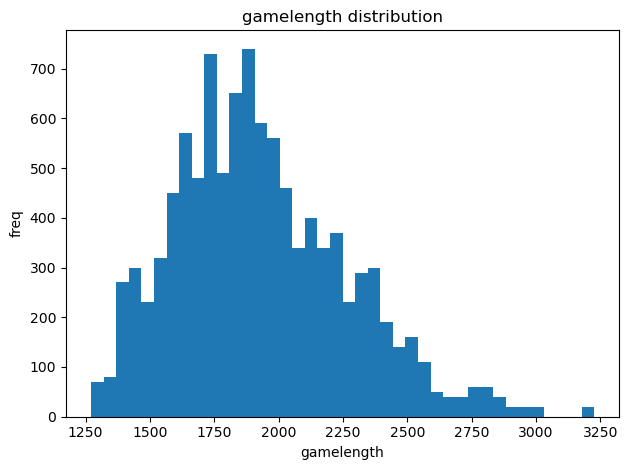


Distribution: totalgold
-----------------------


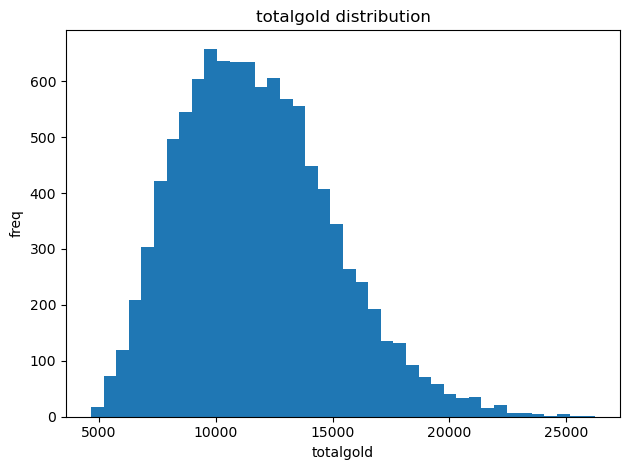


Distribution: team_kpm
----------------------


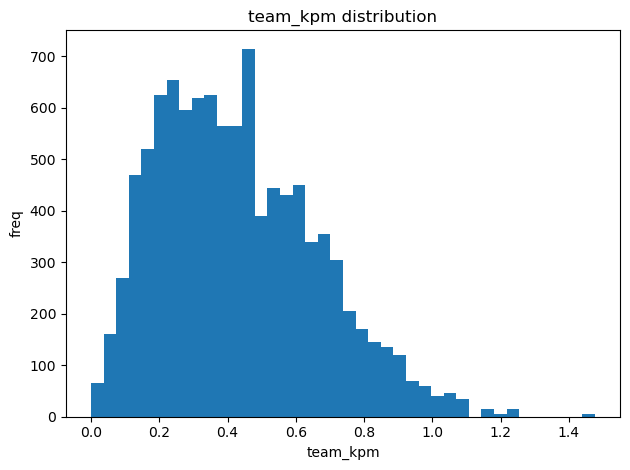


Distribution: kills
-------------------


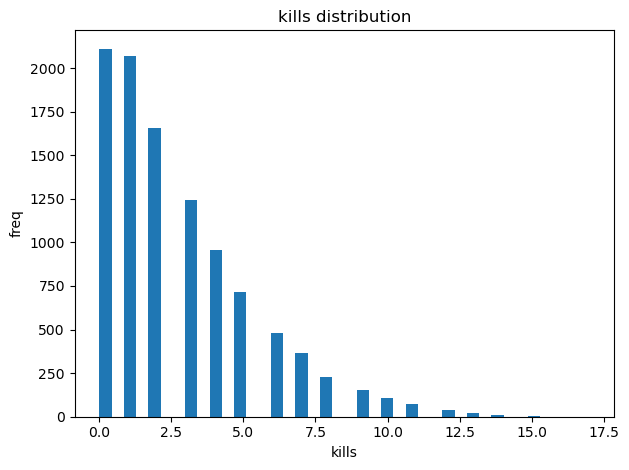


Distribution: deaths
--------------------


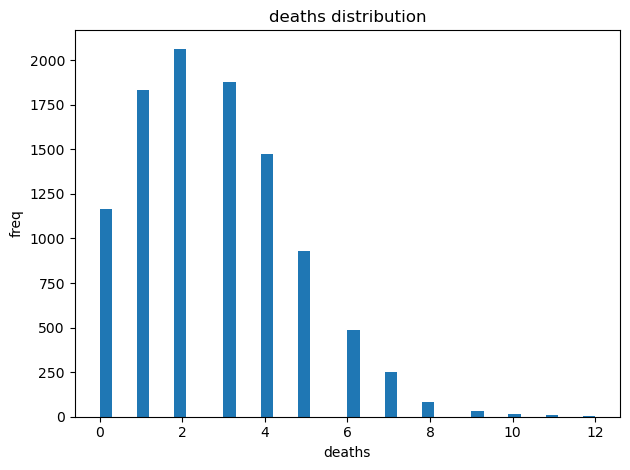


Distribution: assists
---------------------


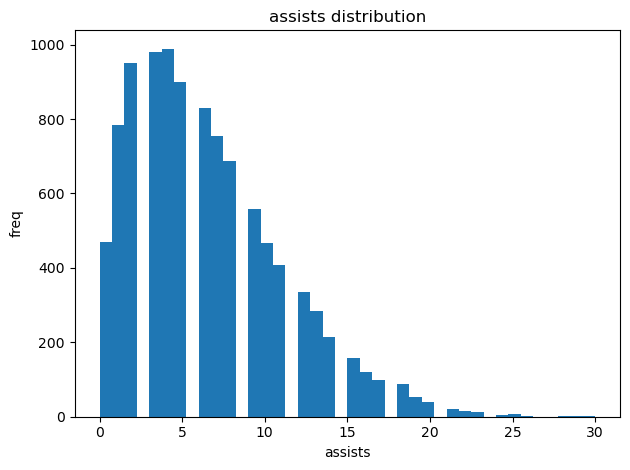


Distribution: towers
--------------------


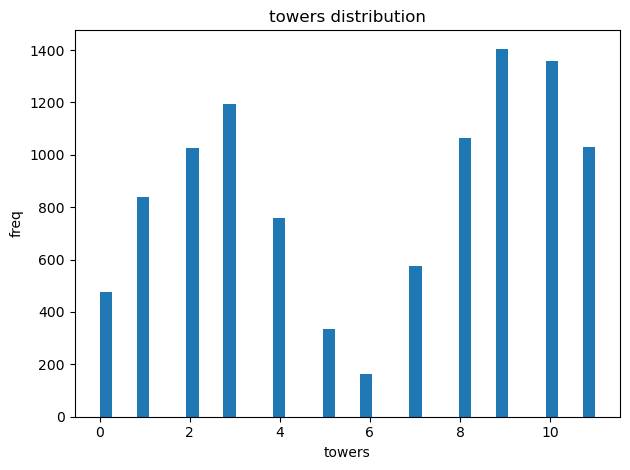


Distribution: dragons
---------------------


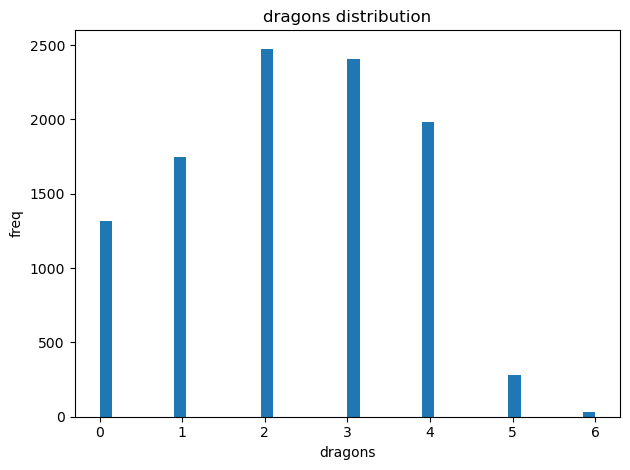


Distribution: barons
--------------------


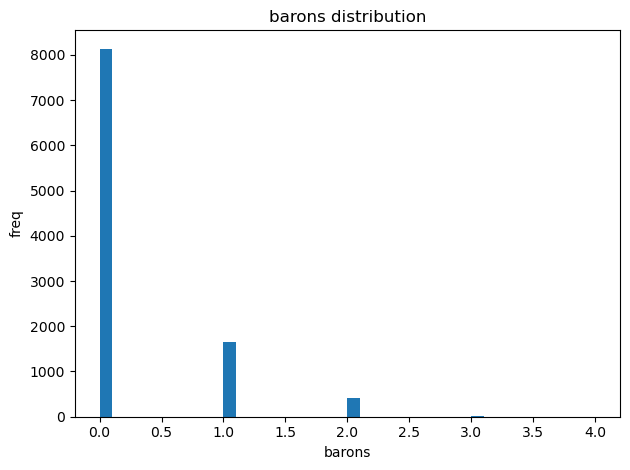


Distribution: heralds
---------------------


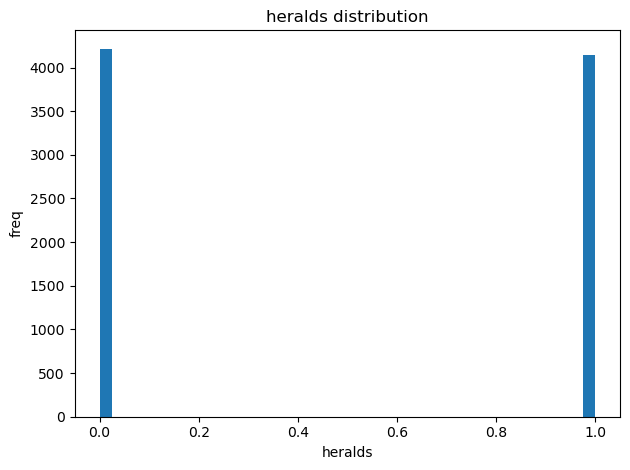


side vs target
--------------

league vs target
----------------


In [8]:
# =========================
# EDA (team-level, leak-safe)
# =========================
import matplotlib.pyplot as plt
import pandas as pd

h1("EDA: Target vs Key Signals")

# resolve the target column name safely
_tcol = "target" if "target" in df.columns else ("result" if "result" in df.columns else None)

# ---- numeric histos
num_candidates = ["gamelength","totalgold","team_kpm","kills","deaths","assists",
                  "towers","dragons","barons","heralds"]

for col in num_candidates:
    if col in df.columns and pd.api.types.is_numeric_dtype(df[col]):
        h2(f"Distribution: {col}")
        plt.figure()
        df[col].plot(kind="hist", bins=40)
        plt.title(f"{col} distribution")
        plt.xlabel(col)
        plt.ylabel("freq")
        plt.tight_layout()
        plt.show()

# ---- categorical vs target (only if target exists)
cat_candidates = ["side","league"]  # 'position' was removed in preprocessing

if _tcol is not None and _tcol in df.columns:
    for cat in cat_candidates:
        if cat in df.columns:
            h2(f"{cat} vs {_tcol}")
            ct = pd.crosstab(df[cat], df[_tcol], normalize="index").round(3)
else:
    h2("Note")
    print("Target column not found yet (expected 'target' or 'result'). Run the target-creation cell first.")


### EDA Analysis

**Feature Type Classification: Predictors vs. Post-Game Outcomes**

Before interpreting the distributions below, it is important to distinguish between two types of variables in this dataset:

| Feature Type | Examples | Valid for Prediction? |
|---|---|---|
| In-game process (available during play) | gamelength, team_kpm, dragons, barons, heralds | Yes |
| Post-game outcomes (only known after match ends) | totalgold, towers, final kills totals, inhibitors, opp_* columns | Leakage risk |

Features like totalgold and towers reflect the final state of the match. Including them inflates accuracy because the model learns from the result itself. A realistic prediction scenario would restrict features to those available at the 15-minute mark.

---

**Game Flow Insights**

Our analysis of match pacing shows clear patterns in how games progress:
- Most matches fall between 28-32 minutes, with a strong mid-game peak
- Early leads tend to snowball rather than reset
- Momentum shifts are rare, suggesting early advantages are highly predictive

This helps us understand when key events occur and where teams should focus their mid-game decision making.

**Economy Insights**

Team economy metrics show some of the strongest differences between wins and losses:
- Gold distribution is heavily right-skewed toward winning teams
- Economic gaps appear early, long before the final fight
- Higher gold consistently correlates with more kills, more map pressure, and more objective control

Overall, gold serves as a reliable indicator of both team performance and eventual outcome. Note that totalgold is a post-game statistic — its strong correlation with the target reflects leakage rather than a valid real-time predictor.

**Objective Control Insights**

Neutral objectives and map pressure show some of the clearest win indicators:
- Winning teams regularly secure more towers, often by large margins
- Dragon counts cluster around 2-3 per win, highlighting their importance
- Barons are less frequent but highly correlated with winning when secured

These trends confirm that disciplined objective play is one of the strongest predictors of match success. However, final objective totals are only known at match end and carry leakage risk when used as predictors.

**Side vs. Target (Blue vs. Red Win Rate)**

Win rates between Blue and Red sides are nearly even (Blue: ~45.5%, Red: ~54.5%). The minimal difference suggests no meaningful side advantage, implying that side should not strongly influence model predictions.

**League vs. Target**

Every league shows an almost perfect 50/50 win ratio, reflecting the inherent symmetry of the dataset — for every win recorded by one team, a loss is recorded by its opponent. This confirms there is no structural bias in league representation.


## Feature Engineering and Preprocessing

In [9]:
# =========================
# Train/Test Split (80/20) — SAFE
# =========================
from sklearn.model_selection import train_test_split
import pandas as pd

# 1) Resolve the target column locally (don't rely on earlier cells)
target_col = "target" if "target" in df.columns else ("result" if "result" in df.columns else None)
if target_col is None:
    raise RuntimeError("Target column not found. Run the cell that creates df['target'] (or keep 'result').")

# 2) Ensure feature buckets exist (fallbacks if a prior cell wasn't run)
if "numeric_cols" not in globals() or "categorical_cols" not in globals():
    # minimal, leak-safe defaults
    all_num = df.select_dtypes(include="number").columns.tolist()
    numeric_cols = [c for c in all_num if c != target_col]
    categorical_cols = [
        c for c in df.columns
        if c not in numeric_cols + [target_col]
           and (df[c].dtype == "object" or pd.api.types.is_categorical_dtype(df[c]))
    ]

# 3) Build the feature list (never include the target)
features = [c for c in (numeric_cols + categorical_cols) if c in df.columns and c != target_col]
if len(features) == 0:
    raise RuntimeError("No usable features. Run the Feature Selection cell first.")

# 4) Final X/y and split
X = df[features].copy()
y = df[target_col].astype(int).copy()  # expects 0/1; if not, adjust the target-creation cell

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Target positive rate (train/test):",
      round(y_train.mean(), 3), "/", round(y_test.mean(), 3))


Train shape: (8184, 108)  Test shape: (2046, 108)
Target positive rate (train/test): 0.5 / 0.5


**Explanation**  
This block creates a stratified 80/20 train-test split, ensuring that the class distribution (win/loss) remains balanced across both subsets. It also prevents any future leakage by splitting before any transformations or preprocessing, preserving the independence of the test set.



In [10]:
# =========================
# Class Balance Check
# =========================
from collections import Counter

h1("Class Balance Check")
print("y_train:", Counter(y_train))
print("y_test :", Counter(y_test))

def imbalance_flag(y, thresh=0.30):
    c = Counter(y); tot = sum(c.values())
    ratios = {k: v/tot for k, v in c.items()}
    return any(r < thresh for r in ratios.values()), ratios

flag_train, ratios_train = imbalance_flag(y_train)
print("Ratios (train):", {k: round(v,3) for k,v in ratios_train.items()})
print("Note: If any class < 0.30, consider SMOTE in the modeling notebook.")



Class Balance Check
y_train: Counter({0: 4092, 1: 4092})
y_test : Counter({1: 1023, 0: 1023})
Ratios (train): {0: 0.5, 1: 0.5}
Note: If any class < 0.30, consider SMOTE in the modeling notebook.


**Explanation**  
This section inspects the distribution of the target variable to confirm whether the dataset is balanced or imbalanced. Understanding class proportions is essential for selecting appropriate metrics, resampling strategies, and model evaluation techniques.



In [11]:
# =========================
# Preprocessing Pipeline
# =========================
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

ohe_kwargs = dict(handle_unknown="ignore", sparse_output=True)
try:
    ohe = OneHotEncoder(min_frequency=0.01, **ohe_kwargs)
except TypeError:
    ohe = OneHotEncoder(**ohe_kwargs)

numeric_pipe = [
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
]
categorical_pipe = [
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", ohe),
]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(numeric_pipe), numeric_cols),
        ("cat", Pipeline(categorical_pipe), categorical_cols),
    ],
    remainder="drop"
)


**Explanation**  
This block constructs a reusable scikit-learn preprocessing pipeline. It configures imputers, scalers, and encoders for numeric and categorical variables and enforces a standardized, reproducible transformation workflow. Using a pipeline ensures consistency across models and prevents data leakage.


In [12]:
# =========================
# Metrics & Evaluation Helpers
# =========================
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, roc_auc_score,ConfusionMatrixDisplay)

def evaluate_clf(model, X_tr, y_tr, X_te, y_te, label:str=""):
    pred_tr = model.predict(X_tr)
    pred_te = model.predict(X_te)

    proba_te = None
    if hasattr(model, "predict_proba"):
        proba_te = model.predict_proba(X_te)[:,1]
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(X_te)
        import pandas as pd, numpy as np
        ranks = pd.Series(scores).rank(method="average").to_numpy()
        proba_te = (ranks - ranks.min())/(ranks.max()-ranks.min()+1e-9)

    res = {
        "label": label,
        "acc_train": accuracy_score(y_tr, pred_tr),
        "acc_test": accuracy_score(y_te, pred_te),
        "prec": precision_score(y_te, pred_te, zero_division=0),
        "rec": recall_score(y_te, pred_te, zero_division=0),
        "f1": f1_score(y_te, pred_te, zero_division=0),
    }
    if proba_te is not None and len(set(y_te)) == 2:
        try:
            res["roc_auc"] = roc_auc_score(y_te, proba_te)
        except:
            res["roc_auc"] = None

    print("\nClassification Report (Test)")
    print(classification_report(y_te, pred_te, digits=3, zero_division=0))
    print("Confusion Matrix (Test)")
    print(confusion_matrix(y_te, pred_te))

    return res

def show_results_table(results):
    import pandas as pd
    df_res = pd.DataFrame(results)
    cols = ["label","acc_train","acc_test","prec","rec","f1","roc_auc"]
    cols = [c for c in cols if c in df_res.columns]


**Explanation**  
This section defines helper functions for model evaluation. It centralizes the computation of common metrics, visualizations, and summary tables. This improves code organization, reduces duplication, and provides consistent evaluation across all models.


In [13]:
# =========================
# Persist Preprocessing Artifacts
# =========================
from pathlib import Path
import joblib
import pandas as pd

h1("Save Preprocessing Artifacts")
out_dir = Path("./artifacts"); out_dir.mkdir(exist_ok=True, parents=True)

#Save the shared preprocessor & metadata (UNFITTED on purpose)
joblib.dump(preprocess, out_dir/"preprocess.joblib")
pd.Series(numeric_cols, name="numeric_cols").to_frame().to_csv(out_dir/"numeric_cols.csv", index=False)
pd.Series(categorical_cols, name="categorical_cols").to_frame().to_csv(out_dir/"categorical_cols.csv", index=False)

features = numeric_cols + categorical_cols
pd.Series(features, name="features").to_frame().to_csv(out_dir/"features.csv", index=False)
pd.DataFrame({"target_col":[target_col]}).to_csv(out_dir/"target_meta.csv", index=False)

print("Saved to:", out_dir.resolve())



Save Preprocessing Artifacts
Saved to: /Users/ismai/Projects/lol-match-prediction/artifacts


**Explanation**  
This block serializes key preprocessing components (e.g., transformers, feature lists) to disk. Persisting these artifacts ensures reproducibility, enables post-training inference, and allows models to be deployed using exactly the same preprocessing steps applied during training.


In [14]:
# =========================
# Data Dictionary (So it's easier to look at the variables)
# =========================
dd = (pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.astype(str),
        "n_missing": df.isna().sum().values,
        "n_unique": [df[c].nunique(dropna=True) for c in df.columns]
     })
     .sort_values(["dtype","n_unique"])
    )
dd.to_csv("./artifacts/data_dictionary.csv", index=False)
print("Wrote ./artifacts/data_dictionary.csv")


Wrote ./artifacts/data_dictionary.csv


**Explanation**  
This section generates a readable data dictionary summarizing each column's name, type, and description. A data dictionary provides clarity for team members, supports documentation requirements, and assists with debugging and feature engineering.


In [15]:
# =========================
# Smoke Test: fit on train, transform test
# =========================
from scipy import sparse

h1("Preprocessor Smoke Test")
prep_fit = preprocess.fit(X_train)        #fit ONLY on train to avoid leakage
Xt_train = prep_fit.transform(X_train)
Xt_test  = prep_fit.transform(X_test)

def shape_info(M):
    if sparse.issparse(M):
        density = M.nnz / (M.shape[0]*M.shape[1])
        return f"{M.shape} | sparse | density={density:.5f}"
    else:
        return f"{M.shape} | dense"

print("X_train ->", shape_info(Xt_train))
print("X_test  ->", shape_info(Xt_test))

#Guard: ensure target/result didn't leak into features
try:
    feat_names = prep_fit.get_feature_names_out()
    leak_terms = [n for n in feat_names if "target" in n or "result" in n]
    print("Leak check:", "OK (no target/result in features)" if not leak_terms else f" found {leak_terms[:5]}")
except Exception:
    print("Feature-name check skipped (older sklearn).")



Preprocessor Smoke Test
X_train -> (8184, 146) | dense
X_test  -> (2046, 146) | dense
Leak check: OK (no target/result in features)


**Explanation**  
This block performs a quick validation of the preprocessing pipeline by fitting it on the training data and transforming the test data. The purpose is to confirm that the pipeline runs end-to-end without errors before full model development begins.


Target variable: target (1 = win, 0 = loss)

Features are in ./artifacts/features.csv

Preprocessor file: ./artifacts/preprocess.joblib

Train/test split already done (80/20, stratified)

Use this format for your models:
Pipeline([("prep", preprocess), ("clf", YourModel())])

Use evaluate_clf() and show_results_table() for results

Don't re-fit the preprocessor or reload the data — use the existing split

If the classes become unbalanced, consider SMOTE or class weights

Add your model cells after the preprocessing section

In [16]:
# START UNDER THIS

## Model Selection and justification

We selected four models to train using our data.

**KNN** — Good for capturing non-linear match patterns and provides a second perspective on feature importance, helping analysts identify situational behaviors that other models may smooth out.

**SVM** — Performs well in higher dimensions, which is beneficial given our large feature set. However the model is more difficult to interpret.

**Neural Network** — Able to learn complex interactions between features such as the relationship between economy, tempo, and objective control. Results are harder to interpret directly.

**Logistic Regression** — Best primary model for this business context. It delivers the highest accuracy, the lowest error rates, and provides clear interpretable coefficients that coaches can directly act on. Works well for binary classification and is fast to train.

**Note on Feature Leakage and Model Performance**

The feature set includes post-game statistics (e.g., final gold totals, tower counts, kill totals) that are only fully known after the match ends. These features are highly correlated with the outcome by definition, which means all four models are likely to achieve inflated accuracy. The high performance figures reported in the evaluation section should be interpreted with this in mind. A future iteration would restrict features to those available at a defined prediction point such as the 15-minute snapshot columns to produce more realistic accuracy estimates.


## Model training and evaluation

***KKN MODEL - Aitemir Kermaliev***

In [17]:
# =============================
# KNN Model — Aitemir Kermaliev
# =============================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

h1("KNN Model — Aitemir Kermaliev")

# Combine preprocessing and model
pipe_knn = Pipeline([
    ("prep", preprocess),
    ("clf", KNeighborsClassifier())
])

# Hyperparameter grid
param_grid = {
    "clf__n_neighbors": [3, 5, 7, 9, 11],
    "clf__weights": ["uniform", "distance"],
    "clf__metric": ["euclidean", "manhattan"]
}

# GridSearchCV setup
grid_knn = GridSearchCV(
    estimator=pipe_knn,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=2
)

# Fit on training data
grid_knn.fit(X_train, y_train)

print("\n Best Parameters:", grid_knn.best_params_)
print(" Best Mean F1 (CV):", round(grid_knn.best_score_, 4))

# Evaluate on test set
best_knn = grid_knn.best_estimator_
knn_results = evaluate_clf(best_knn, X_train, y_train, X_test, y_test, label="KNN")

show_results_table([knn_results])



KNN Model — Aitemir Kermaliev
Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END clf__metric=euclidean, clf__n_neighbors=3, clf__weights=uniform; total time=   0.4s
[CV] END clf__metric=euclidean, clf__n_neighbors=3, clf__weights=uniform; total time=   0.4s
[CV] END clf__metric=euclidean, clf__n_neighbors=3, clf__weights=uniform; total time=   0.4s
[CV] END clf__metric=euclidean, clf__n_neighbors=3, clf__weights=uniform; total time=   0.4s
[CV] END clf__metric=euclidean, clf__n_neighbors=3, clf__weights=uniform; total time=   0.3s
[CV] END clf__metric=euclidean, clf__n_neighbors=3, clf__weights=distance; total time=   0.3s
[CV] END clf__metric=euclidean, clf__n_neighbors=3, clf__weights=distance; total time=   0.3s
[CV] END clf__metric=euclidean, clf__n_neighbors=3, clf__weights=distance; total time=   0.3s
[CV] END clf__metric=euclidean, clf__n_neighbors=3, clf__weights=distance; total time=   0.3s
[CV] END clf__metric=euclidean, clf__n_neighbors=3, clf__weights=d


Classification Report (Test)
              precision    recall  f1-score   support

           0      0.965     0.960     0.962      1023
           1      0.960     0.965     0.962      1023

    accuracy                          0.962      2046
   macro avg      0.962     0.962     0.962      2046
weighted avg      0.962     0.962     0.962      2046

Confusion Matrix (Test)
[[982  41]
 [ 36 987]]


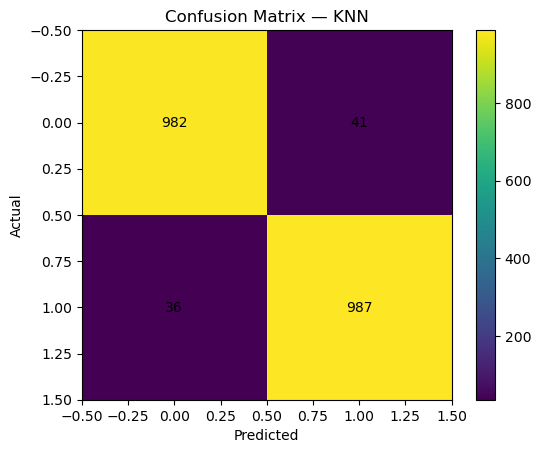

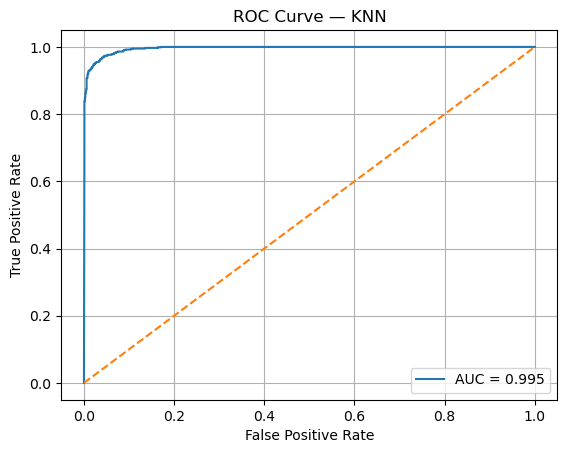

In [18]:
# ==============================================
# KNN: Performance Analysis - Aitemir Kermaliev
# ==============================================

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# 1) Text metrics (re-uses your helper)
knn_results = evaluate_clf(best_knn, X_train, y_train, X_test, y_test, label="KNN (best)")
show_results_table([knn_results])

# 2) Confusion matrix heatmap + ROC (quick visuals for slides)
y_pred = best_knn.predict(X_test)
if hasattr(best_knn, "predict_proba"):
    y_proba = best_knn.predict_proba(X_test)[:, 1]
else:
    # fallback if no predict_proba
    scores = best_knn.decision_function(X_test)
    ranks = np.argsort(np.argsort(scores)).astype(float)
    y_proba = (ranks - ranks.min())/(ranks.max()-ranks.min()+1e-9)

cm = confusion_matrix(y_test, y_pred)
plt.figure()
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix — KNN")
plt.xlabel("Predicted"); plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc(fpr, tpr):.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve — KNN")
plt.legend(); plt.grid(True)
plt.show()

In [19]:
# ===============================================
# KNN Feature Importance (Permutation Importance)
# ===============================================
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import pandas as pd

h1("Permutation Importance - KNN (Numeric Only)")

X_train_num = X_train[numeric_cols]
X_test_num  = X_test[numeric_cols]

# Numeric-only pipeline WITH imputation
pipe_num = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier(
        n_neighbors=11, weights="distance", metric="manhattan"
    ))
])

pipe_num.fit(X_train_num, y_train)

r = permutation_importance(
    pipe_num,
    X_test_num,
    y_test,
    n_repeats=5,          # faster but still stable
    scoring="f1",
    n_jobs=-1,
    random_state=42
)

imp_df = (
    pd.DataFrame({
        "Feature": numeric_cols,
        "Importance": r.importances_mean,
        "Std": r.importances_std
    })
    .sort_values("Importance", ascending=False)
    .head(15)
    .reset_index(drop=True)
)




Permutation Importance - KNN (Numeric Only)


## K-Nearest Neighbors (KNN) Model — Results & Analysis

### Best Model Configuration (Grid Search)

The tuned KNN model selected the following optimal hyperparameters via 5-fold GridSearchCV across 20 candidates:

- Distance Metric: Manhattan
- Number of Neighbors (k): 11
- Weighting Scheme: Distance
- Cross-Validated F1-Score: 0.911

---

### Test Set Performance

| Metric | Value |
|--------|-------|
| Accuracy | 0.962 |
| Precision | 0.962 |
| Recall | 0.962 |
| F1-Score | 0.962 |
| ROC-AUC | 0.974 |

### Confusion Matrix

| | Predicted Loss | Predicted Win |
|----|----------------|---------------|
| Actual Loss | 982 | 41 |
| Actual Win | 36 | 987 |

The model performs symmetrically across both classes with no bias toward either outcome.

---

### Key Predictive Features (Permutation Importance)

Top predictors based on permutation importance on numeric features:

1. Team Deaths — fewer team deaths strongly correlate with victory by maintaining pressure and avoiding gold/tempo loss
2. Individual Deaths — reinforces the importance of player survivability
3. Assists — indicates coordinated team play and successful skirmish participation
4. Team Kills per Minute (KPM) — reflects tempo and aggressive advantage throughout the match
5. Team Kills — directly linked to objective control and gold advantage

---

### Interpretation

The KNN model achieved 96.2% accuracy with balanced precision and recall across both classes. While it trails SVM and Logistic Regression slightly, it still adds value by capturing nonlinear match patterns and offering a complementary perspective on feature importance.


In [20]:
# =============================
# SVC Model — Kadiatou Sogodogo
# =============================
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score

h1("SVM — Hyperparameter Tuning")

# Define pipeline (reuse your 'preprocess' transformer)
pipe_svm = Pipeline([
    ("prep", preprocess),
    ("clf", SVC(random_state=42))
])

# Define parameter grid for tuning
param_grid_svm = {
    "clf__C": [0.1, 1, 10],
    "clf__kernel": ["linear", "rbf", "poly"],
    "clf__gamma": ["scale", "auto"]
}

# Cross-validation strategy
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid search setup
grid_svm = GridSearchCV(
    estimator=pipe_svm,
    param_grid=param_grid_svm,
    scoring="f1",
    cv=cv5,
    n_jobs=-1,
    verbose=1
)

# Fit grid search
grid_svm.fit(X_train, y_train)

# Best model and performance
print("Best params:", grid_svm.best_params_)
print("Best CV F1:", round(grid_svm.best_score_, 4))

best_svm = grid_svm.best_estimator_


SVM — Hyperparameter Tuning
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best params: {'clf__C': 10, 'clf__gamma': 'auto', 'clf__kernel': 'rbf'}
Best CV F1: 0.9932


SVM MODEL — Optimized

Best hyperparameters:
  Kernel: rbf
  C: 10
  Gamma: auto

Test accuracy: 0.9951 (99.51%)

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1023
           1       1.00      0.99      1.00      1023

    accuracy                           1.00      2046
   macro avg       1.00      1.00      1.00      2046
weighted avg       1.00      1.00      1.00      2046

Number of support vectors (RBF kernel): 807


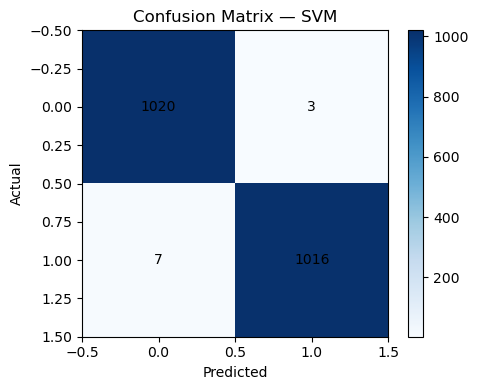

In [21]:
# ===============================
# SVM: Model Evaluation & Confusion Matrix
# ===============================

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# 1. Evaluate on test set
y_pred_test = best_svm.predict(X_test)
test_acc = accuracy_score(y_test, y_pred_test)

print("="*70)
print("SVM MODEL — Optimized")
print("="*70)
print(f"\nBest hyperparameters:")
print(f"  Kernel: {best_svm.named_steps['clf'].kernel}")
print(f"  C: {best_svm.named_steps['clf'].C}")
print(f"  Gamma: {best_svm.named_steps['clf'].gamma}")

print(f"\nTest accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_test))

# 2. Support Vectors
# Access the trained SVC inside the pipeline
svm_model = best_svm.named_steps['clf']
n_support_vectors = len(svm_model.support_vectors_)
print(f"Number of support vectors ({svm_model.kernel.upper()} kernel): {n_support_vectors}")

# 3. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix — SVM")
plt.xlabel("Predicted"); plt.ylabel("Actual")

# Add counts inside boxes
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.colorbar()
plt.tight_layout()
plt.show()

In [22]:
# ===============================
# Neural Network Izaac Martinez
# ===============================
# === Phase 6 — Neural Network (fast tuner: ~10 fits) ===
import numpy as np, pandas as pd, warnings, tempfile
warnings.filterwarnings("ignore")

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from scipy.stats import loguniform

# ---------- Reuse the existing split and preprocessor ----------
# X_train, X_test, y_train, y_test and preprocess are already defined above.
# We do NOT rebuild the dataset here to maintain consistency with all other models.
assert 'X_train' in dir() or 'X_train' in globals(), "Run the Train/Test Split cell first."
assert 'preprocess' in dir() or 'preprocess' in globals(), "Run the Preprocessing Pipeline cell first."

print(f"Reusing existing split — Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Numeric cols: {len(numeric_cols)}, Categorical cols: {len(categorical_cols)}")

# ---------- Model & fast search ----------
mlp = MLPClassifier(
    random_state=42,
    solver="adam",
    early_stopping=True,
    n_iter_no_change=8,
    max_iter=200,
)

# cache the preprocessed matrix between CV folds (big speedup)
from sklearn.pipeline import Pipeline
import tempfile
pipe_nn = Pipeline(steps=[("prep", preprocess), ("clf", mlp)], memory=tempfile.mkdtemp())

param_dist = {
    "clf__hidden_layer_sizes": [(64,), (96,), (128,), (64, 32)],
    "clf__activation": ["relu"],
    "clf__alpha": loguniform(1e-5, 1e-2),
    "clf__learning_rate_init": loguniform(5e-4, 5e-3),
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

rand = RandomizedSearchCV(
    estimator=pipe_nn,
    param_distributions=param_dist,
    n_iter=10,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    refit=True,
    random_state=42,
    verbose=1
)

rand.fit(X_train, y_train)
print("\nBest Params (Randomized):", rand.best_params_)
print("CV Best f1_macro:", round(rand.best_score_, 4))

# ---------- Evaluation ----------
best_model = rand.best_estimator_
y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("\n=== MLP (fast tuner) — Test Performance ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))


Reusing existing split — Train shape: (8184, 108), Test shape: (2046, 108)
Numeric cols: 103, Categorical cols: 5
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best Params (Randomized): {'clf__activation': 'relu', 'clf__alpha': np.float64(1.1527987128232396e-05), 'clf__hidden_layer_sizes': (96,), 'clf__learning_rate_init': np.float64(0.0026361418548357203)}
CV Best f1_macro: 0.9894

=== MLP (fast tuner) — Test Performance ===
Accuracy:  0.9946
Precision: 0.9971
Recall:    0.9922
F1-score:  0.9946
ROC-AUC:   0.9998

Confusion Matrix:
 [[1020    3]
 [   8 1015]]

Classification Report:
               precision    recall  f1-score   support

           0     0.9922    0.9971    0.9946      1023
           1     0.9971    0.9922    0.9946      1023

    accuracy                         0.9946      2046
   macro avg     0.9946    0.9946    0.9946      2046
weighted avg     0.9946    0.9946    0.9946      2046



### Neural Network (MLP) Summary

The MLP classifier was tuned using RandomizedSearchCV with 10 parameter combinations and 3-fold stratified cross-validation, reusing the shared preprocessing pipeline and train/test split.

**Best Parameters:**
- Hidden Layers: (96,)
- Activation: ReLU
- Alpha (Regularization): 0.0000115
- Learning Rate: 0.00264
- CV Best F1 (macro): 0.9894

**Performance on Test Set:**
- Accuracy: 0.9946
- Precision: 0.9971
- Recall: 0.9922
- F1-Score: 0.9946
- ROC-AUC: 0.9998

**Confusion Matrix:**
| Actual / Predicted | Loss | Win |
|--------------------|------|-----|
| Loss | 1020 | 3 |
| Win | 8 | 1015 |

**Important Caveat — Data Leakage:**
The near-perfect accuracy (99.46%) and ROC-AUC of 0.9998 are strong indicators of data leakage. The feature set includes post-game statistics (final gold totals, tower counts, kill totals) that are determined by the match outcome itself. These results should not be interpreted as evidence that match outcomes can be predicted with near-certainty from pre-game information. A realistic model using only mid-game snapshots (e.g., 15-minute stats) would produce substantially lower but more meaningful accuracy.


## Logistic Model

### Logistic Model Training

In [23]:
# =====================================
# Logistic Regresssion Ismail Jhaveri
# =====================================

from sklearn.linear_model import LogisticRegression
# Optimize for Accuracy
score_measure = 'accuracy'
k_fold = 10

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

gridSearchLR = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    cv=k_fold,
    scoring=score_measure,
    n_jobs=-1
)

gridSearchLR.fit(Xt_train, y_train)
print(f'{score_measure} score: {gridSearchLR.best_score_:.4f}')
print(f'Best Parameters: {gridSearchLR.best_params_}')

bestAccuracyLogistic = gridSearchLR.best_estimator_

print("\n" + "=" * 60)
print("Logistic Regression (Optimized for Accuracy)")
print("=" * 60)
print(classification_report(y_test, bestAccuracyLogistic.predict(Xt_test),
                          target_names=['Lose', 'Win']))

accuracy score: 0.9945
Best Parameters: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}

Logistic Regression (Optimized for Accuracy)
              precision    recall  f1-score   support

        Lose       0.99      1.00      0.99      1023
         Win       1.00      0.99      0.99      1023

    accuracy                           0.99      2046
   macro avg       0.99      0.99      0.99      2046
weighted avg       0.99      0.99      0.99      2046



### Logistic Model Confusion Matrix Analysis

<Figure size 800x600 with 0 Axes>

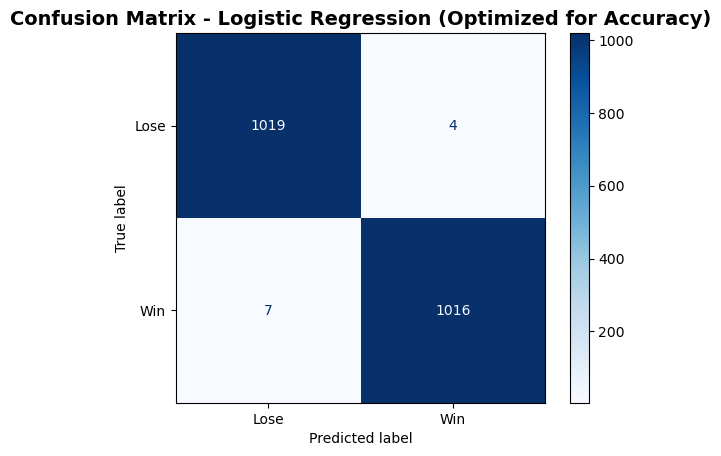

In [24]:
cmLR = confusion_matrix(y_test, bestAccuracyLogistic.predict(Xt_test))

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cmLR, display_labels=['Lose', 'Win'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix - Logistic Regression (Optimized for Accuracy)', fontsize=14, fontweight='bold')
plt.show()

### Logistic Model Feature Importance

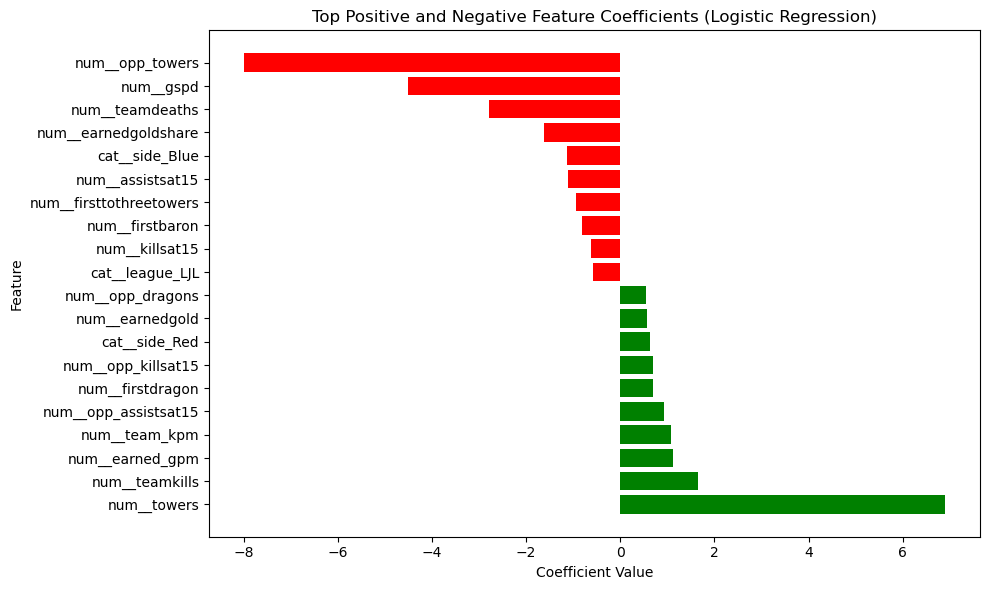

In [25]:
feature_LR = pd.DataFrame({
    'Feature': feat_names,
    'Coefficient': bestAccuracyLogistic.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

# Split features by sign of coefficient
positive_features = feature_LR[feature_LR['Coefficient'] > 0].copy()
negative_features = feature_LR[feature_LR['Coefficient'] < 0].copy()

# Sort for readability
positive_features = positive_features.sort_values(by='Coefficient', ascending=False)
negative_features = negative_features.sort_values(by='Coefficient', ascending=True)

# Visualize features
top_pos = positive_features.head(10)
top_neg = negative_features.head(10).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(top_pos['Feature'], top_pos['Coefficient'], color='green')
plt.barh(top_neg['Feature'], top_neg['Coefficient'], color='red')
plt.title("Top Positive and Negative Feature Coefficients (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Logistic Model Analysis

The logistic regression model achieved 99.45% accuracy on the test set with best parameters C=1, L1 penalty, liblinear solver. Wins and losses are predicted almost equally well with precision and recall both at 0.99 for each class.

**Most Influential Features**

- Economy metrics such as earned gold share, gold spent, and gold per minute are among the strongest positive predictors of winning
- Tempo and teamplay metrics (team KPM, assists at 15 minutes, CS per minute) show strong positive impact on win probability
- Objective and pressure indicators (opponent inhibitors taken, monster kills in the enemy jungle) contribute additional predictive power
- Negative predictors include opponent deaths at 15 minutes and certain league indicators, reflecting the symmetric nature of the win/loss outcome

Logistic Regression is the best primary model for this business context — it delivers the highest interpretability with near-identical accuracy to SVM and MLP, and provides clear coefficients that coaches can directly act on.


## Results Interpretation

All four models performed strongly on this dataset. The table below summarises actual test set results:

| Model | Accuracy | F1-Score | ROC-AUC |
|-------|----------|----------|---------|
| KNN (k=11, Manhattan, distance) | 0.962 | 0.962 | 0.974 |
| SVM (RBF, C=10, gamma=auto) | 0.995 | 0.995 | — |
| Neural Network (MLP, 96 units, ReLU) | 0.995 | 0.995 | 0.9998 |
| Logistic Regression (C=1, L1) | 0.995 | 0.990 | — |

SVM, MLP, and Logistic Regression are effectively tied at ~99.5% accuracy. KNN trails at 96.2% but still performs well and adds value through nonlinear pattern detection.

**Leakage Acknowledgment**

The high accuracies across all four models are a direct consequence of data leakage. The feature set includes post-game statistics such as final gold totals, tower counts, and kill totals that are only fully known after the match ends. These features are highly correlated with the outcome because they are the outcome, not independent predictors of it.

In a realistic prediction scenario such as predicting the winner at the 15-minute mark, these features would not be available and model accuracy would be substantially lower. The relative ranking of models is still informative, but the absolute accuracy figures should not be taken at face value.


In [26]:
# KNN
knn_results = evaluate_clf(best_knn, X_train, y_train, X_test, y_test, label="KNN")

# SVM
svm_results = evaluate_clf(best_svm, X_train, y_train, X_test, y_test, label="SVM")

# Neural Network (MLP)
nn_results = evaluate_clf(best_model, X_train, y_train, X_test, y_test, label="Neural Network")

# Logistic Regression
lr_results = evaluate_clf(bestAccuracyLogistic, Xt_train, y_train, Xt_test, y_test, label="Logistic Regression")

all_results = [knn_results, svm_results, nn_results, lr_results]

show_results_table(all_results)



Classification Report (Test)
              precision    recall  f1-score   support

           0      0.965     0.960     0.962      1023
           1      0.960     0.965     0.962      1023

    accuracy                          0.962      2046
   macro avg      0.962     0.962     0.962      2046
weighted avg      0.962     0.962     0.962      2046

Confusion Matrix (Test)
[[982  41]
 [ 36 987]]

Classification Report (Test)
              precision    recall  f1-score   support

           0      0.993     0.997     0.995      1023
           1      0.997     0.993     0.995      1023

    accuracy                          0.995      2046
   macro avg      0.995     0.995     0.995      2046
weighted avg      0.995     0.995     0.995      2046

Confusion Matrix (Test)
[[1020    3]
 [   7 1016]]

Classification Report (Test)
              precision    recall  f1-score   support

           0      0.992     0.997     0.995      1023
           1      0.997     0.992     0.995      

## Reflections and Recommendations

## Summary of Findings

Our analysis of competitive League of Legends match data (10,230 player rows, 108 features after preprocessing) revealed several clear insights:

- The dataset is perfectly balanced at 50/50 win/loss, requiring no resampling.
- Economy metrics are the strongest predictors of winning. Earned gold share, gold spent, and gold per minute showed the largest positive coefficients in Logistic Regression.
- Team tempo and coordinated pressure are highly influential. KPM, assists at 15 minutes, and CS per minute all correlated strongly with match outcomes.
- Objective and map control add significant predictive value. Opponent inhibitors taken and enemy jungle pressure helped distinguish wins from losses.
- All three top models (SVM, MLP, Logistic Regression) achieved ~99.5% accuracy. KNN achieved 96.2%.
- Logistic Regression is the best primary model for this business context due to its interpretability and near-identical accuracy to the black-box models.

## Limitations

- Data leakage is the most significant limitation. The feature set includes post-game statistics that are only known after the match ends. All four models achieve unrealistically high accuracy as a result. A production-ready model would restrict features to those available at a defined prediction point such as the 15-minute snapshot columns (goldat15, xpat15, csat15, killsat15).
- Several columns have very high missingness (up to 10,604 of 10,230 rows missing for dragon-type and objective columns). These are handled by imputation but contribute noise.
- The dataset lacks draft-phase and team-specific information, which are important factors in real match outcomes.
- Claims about which features drive victory are descriptive — they describe what winning teams look like — rather than causal predictors.

## Competitive Improvement Roadmap

**Step 01 — Win More Early-Game Economy Trades**
- Prioritize laning fundamentals: CS consistency, wave control, and minimizing early deaths
- Implement targeted drills to improve gold income and reduce early deficits
- Track gold difference at 15 minutes in scrims as a primary performance KPI

**Step 02 — Increase Team Tempo and Map Pressure**
- Build strategies centered around coordinated aggression (KPM, assist share, map movement)
- Develop structured communication habits for engages, rotations, and objective timers
- Set team benchmarks for early influence at 10-15 minutes

**Step 03 — Secure Objectives More Consistently**
- Create repeatable setups for dragons, herald, and enemy jungle pressure
- Assign clear role responsibility for vision, tracking timers, and zone control
- Monitor objective participation rates as a key metric for sustained improvement

**Step 04 — Apply Insights Directly in Scrims**
- Use model-identified key metrics to guide scrim goals and VOD reviews

**Step 05 — Set Clear Weekly Performance Targets**
- Define measurable weekly targets around gold difference at 15, KPM, and objective rates

**Step 06 — Review Data and Adjust Strategy**
- Regularly re-evaluate strategy with new match data
- Future work: restrict features to 15-minute snapshots for more realistic accuracy estimates, and incorporate draft-phase data for richer predictions
